In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/nifty_options_clean.csv")
df["date"]   = pd.to_datetime(df["date"])
df["expiry"] = pd.to_datetime(df["expiry"])

print(f"Shape: {df.shape}")
df.head()

Shape: (202509, 14)


,date,symbol,expiry,strike,option_type,open,high,low,close,settle_price,underlying_price,open_interest,oi_change,volume
0,2024-12-02,NIFTY,2025-03-27,23000.0,CE,1800.00,2018.0,1769.15,1981.10,1981.10,24276.05,171350.0,-100.0,306.0
1,2024-12-02,NIFTY,2024-12-12,23000.0,PE,16.00,21.8,12.00,13.10,13.10,24276.05,749525.0,235100.0,76449.0
2,2024-12-02,NIFTY,2025-01-30,23000.0,CE,1457.85,1713.7,1455.25,1681.30,1681.30,24276.05,91925.0,1100.0,306.0
3,2024-12-02,NIFTY,2024-12-19,23550.0,CE,0.00,0.0,0.00,945.65,845.95,24276.05,0.0,0.0,0.0
4,2024-12-02,NIFTY,2025-01-30,23550.0,CE,1138.80,1138.8,1138.80,1138.80,1155.30,24276.05,4075.0,25.0,1.0


In [4]:
# ── Days to Expiry (DTE) ───────────────────────────────
df["dte"] = (df["expiry"] - df["date"]).dt.days

# ── ATM classification ─────────────────────────────────
# ATM = strike within 1% of underlying price
df["atm_distance"] = abs(df["strike"] - df["underlying_price"]) / df["underlying_price"] * 100

def classify_moneyness(row):
    dist = row["atm_distance"]
    if dist <= 1:
        return "ATM"
    elif row["option_type"] == "CE":
        return "OTM" if row["strike"] > row["underlying_price"] else "ITM"
    else:
        return "OTM" if row["strike"] < row["underlying_price"] else "ITM"

df["moneyness"] = df.apply(classify_moneyness, axis=1)

# ── Expiry week flag ───────────────────────────────────
df["is_expiry_week"] = df["dte"] <= 7

# ── Weekly vs Monthly expiry ───────────────────────────
# Weekly = expires on Thursday, Monthly = last Thursday of month
df["expiry_day"] = df["expiry"].dt.day_name()
df["expiry_month"] = df["expiry"].dt.to_period("M")

print(f"DTE range: {df['dte'].min()} → {df['dte'].max()}")
print(f"\nMoneyness distribution:\n{df['moneyness'].value_counts()}")
print(f"\nSample data:")
df[["date","expiry","strike","option_type","close","dte","moneyness"]].head(10)

DTE range: 0 → 1826

Moneyness distribution:
moneyness
OTM    93667
ITM    91684
ATM    17158
Name: count, dtype: int64

Sample data:


,date,expiry,strike,option_type,close,dte,moneyness
0,2024-12-02,2025-03-27,23000.0,CE,1981.10,115,ITM
1,2024-12-02,2024-12-12,23000.0,PE,13.10,10,OTM
2,2024-12-02,2025-01-30,23000.0,CE,1681.30,59,ITM
3,2024-12-02,2024-12-19,23550.0,CE,945.65,17,ITM
4,2024-12-02,2025-01-30,23550.0,CE,1138.80,59,ITM
5,2024-12-02,2025-02-27,23000.0,CE,1604.65,87,ITM
6,2024-12-02,2025-02-27,24550.0,CE,693.75,87,OTM
7,2024-12-02,2026-12-31,23000.0,PE,625.00,759,OTM
8,2024-12-02,2024-12-19,24550.0,PE,376.50,17,ITM
9,2024-12-02,2028-12-28,23000.0,CE,6377.60,1487,ITM


In [6]:
# ── Filter: only expiries within 30 days (weekly/monthly) ─
df_near = df[df["dte"] <= 30].copy()
print(f"Near-term records: {len(df_near):,}")
print(f"Unique expiries: {df_near['expiry'].nunique()}")

# ── Theta Decay: ATM options only ─────────────────────────
# Focus on last 15 days before expiry
atm_decay = df_near[
    (df_near["moneyness"] == "ATM") &
    (df_near["dte"] <= 15) &
    (df_near["close"] > 0)
].copy()

# Average premium by DTE across all expiry cycles
decay_curve = atm_decay.groupby(["dte", "option_type"])["close"].median().reset_index()
decay_curve.columns = ["dte", "option_type", "median_premium"]
decay_curve = decay_curve.sort_values("dte", ascending=False)

print(f"\nATM decay records: {len(atm_decay):,}")
print(decay_curve.head(20))

Near-term records: 110,000
Unique expiries: 30

ATM decay records: 5,522
    dte option_type  median_premium
27   15          PE         258.975
26   15          CE         328.100
25   14          PE         239.150
24   14          CE         298.550
23   13          PE         236.575
22   13          CE         290.600
21   12          PE         174.350
20   12          CE         216.325
19   10          PE         216.150
18   10          CE         276.150
17    9          PE         205.075
16    9          CE         251.775
15    8          PE         198.850
14    8          CE         230.750
13    7          PE         176.450
12    7          CE         202.550
11    6          PE         164.750
10    6          CE         182.400
9     5          PE         150.650
8     5          CE         146.750


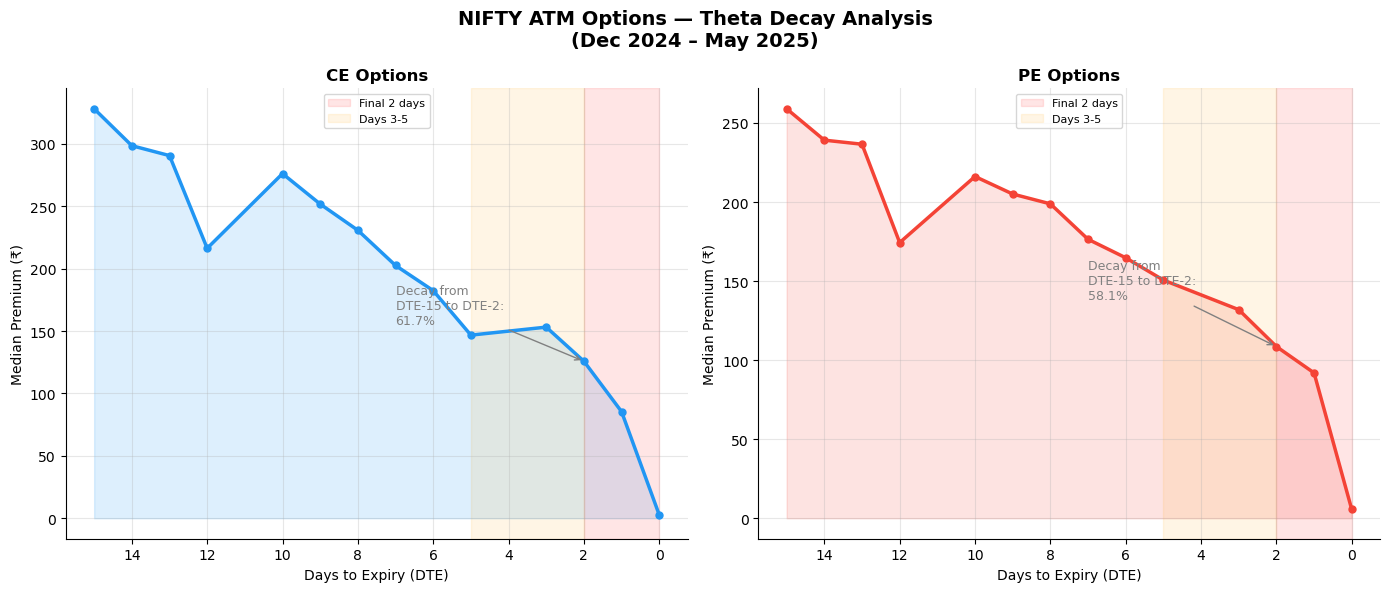

✅ Chart saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("NIFTY ATM Options — Theta Decay Analysis\n(Dec 2024 – May 2025)", 
             fontsize=14, fontweight="bold")

colors = {"CE": "#2196F3", "PE": "#F44336"}

for ax, opt_type in zip(axes, ["CE", "PE"]):
    data = decay_curve[decay_curve["option_type"] == opt_type].sort_values("dte")
    
    ax.plot(data["dte"], data["median_premium"], 
            color=colors[opt_type], linewidth=2.5, marker="o", markersize=5)
    ax.fill_between(data["dte"], data["median_premium"], 
                    alpha=0.15, color=colors[opt_type])
    
    # Mark key zones
    ax.axvspan(0, 2, alpha=0.1, color="red", label="Final 2 days")
    ax.axvspan(2, 5, alpha=0.1, color="orange", label="Days 3-5")
    
    # Annotations
    d15 = data[data["dte"]==15]["median_premium"].values
    d2  = data[data["dte"]==2]["median_premium"].values
    d0  = data[data["dte"]==0]["median_premium"].values
    
    if len(d15) and len(d2):
        decay_pct = ((d15[0] - d2[0]) / d15[0] * 100)
        ax.annotate(f"Decay from\nDTE-15 to DTE-2:\n{decay_pct:.1f}%",
                    xy=(2, d2[0]), xytext=(7, d2[0]+30),
                    arrowprops=dict(arrowstyle="->", color="gray"),
                    fontsize=9, color="gray")
    
    ax.set_title(f"{opt_type} Options", fontsize=12, fontweight="bold")
    ax.set_xlabel("Days to Expiry (DTE)", fontsize=10)
    ax.set_ylabel("Median Premium (₹)", fontsize=10)
    ax.invert_xaxis()  # left=far from expiry, right=expiry day
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../data/processed/theta_decay.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

In [9]:
# ── Open Interest Buildup Analysis ─────────────────────
# Focus on expiry week only (DTE <= 7)

oi_expiry = df_near[
    (df_near["dte"] <= 7) &
    (df_near["open_interest"] > 0)
].copy()

# Total OI by strike and option type on each day
oi_by_strike = oi_expiry.groupby(
    ["date", "strike", "option_type"]
)["open_interest"].sum().reset_index()

# ── Max Pain Calculation ───────────────────────────────
def calculate_max_pain(expiry_date, df):
    """Max pain = strike where total option writers lose least"""
    day_data = df[df["expiry"] == expiry_date].copy()
    if day_data.empty:
        return None
    
    strikes = day_data["strike"].unique()
    pain = {}
    
    for s in strikes:
        ce_loss = day_data[
            (day_data["option_type"] == "CE") & 
            (day_data["strike"] < s)
        ]["open_interest"].sum() * (s - day_data[
            (day_data["option_type"] == "CE") & 
            (day_data["strike"] < s)
        ]["strike"]).mean()
        
        pe_loss = day_data[
            (day_data["option_type"] == "PE") & 
            (day_data["strike"] > s)
        ]["open_interest"].sum() * (day_data[
            (day_data["option_type"] == "PE") & 
            (day_data["strike"] > s)
        ]["strike"] - s).mean()
        
        pain[s] = (0 if np.isnan(ce_loss) else ce_loss) + \
                  (0 if np.isnan(pe_loss) else pe_loss)
    
    return min(pain, key=pain.get)

# Calculate max pain for each expiry
expiries = df_near["expiry"].unique()
max_pain_results = []

for exp in sorted(expiries):
    exp_data = df_near[
        (df_near["expiry"] == exp) & 
        (df_near["dte"] == 0)
    ]
    if exp_data.empty:
        # use last available day for that expiry
        exp_data = df_near[
            (df_near["expiry"] == exp) &
            (df_near["dte"] == df_near[df_near["expiry"]==exp]["dte"].min())
        ]
    
    mp = calculate_max_pain(exp, exp_data)
    underlying = exp_data["underlying_price"].median()
    
    if mp and underlying:
        max_pain_results.append({
            "expiry": exp,
            "max_pain": mp,
            "underlying_close": underlying,
            "difference": abs(mp - underlying),
            "diff_pct": abs(mp - underlying) / underlying * 100
        })

mp_df = pd.DataFrame(max_pain_results)
mp_df["expiry"] = pd.to_datetime(mp_df["expiry"])
mp_df = mp_df.sort_values("expiry")

print(f"Max Pain calculated for {len(mp_df)} expiries")
print(f"\nAverage distance from max pain to close: {mp_df['diff_pct'].mean():.2f}%")
print(f"\nSample:")
print(mp_df.head(10).to_string(index=False))

Max Pain calculated for 30 expiries

Average distance from max pain to close: 0.24%

Sample:
    expiry  max_pain  underlying_close  difference  diff_pct
2024-12-05   24500.0          24708.40      208.40  0.843438
2024-12-12   24550.0          24548.70        1.30  0.005296
2024-12-19   23950.0          23951.70        1.70  0.007098
2024-12-26   23750.0          23750.20        0.20  0.000842
2025-01-02   24200.0          24188.65       11.35  0.046923
2025-01-09   23550.0          23526.50       23.50  0.099887
2025-01-16   23300.0          23311.80       11.80  0.050618
2025-01-23   23200.0          23205.35        5.35  0.023055
2025-01-30   23250.0          23249.50        0.50  0.002151
2025-02-06   23600.0          23603.35        3.35  0.014193


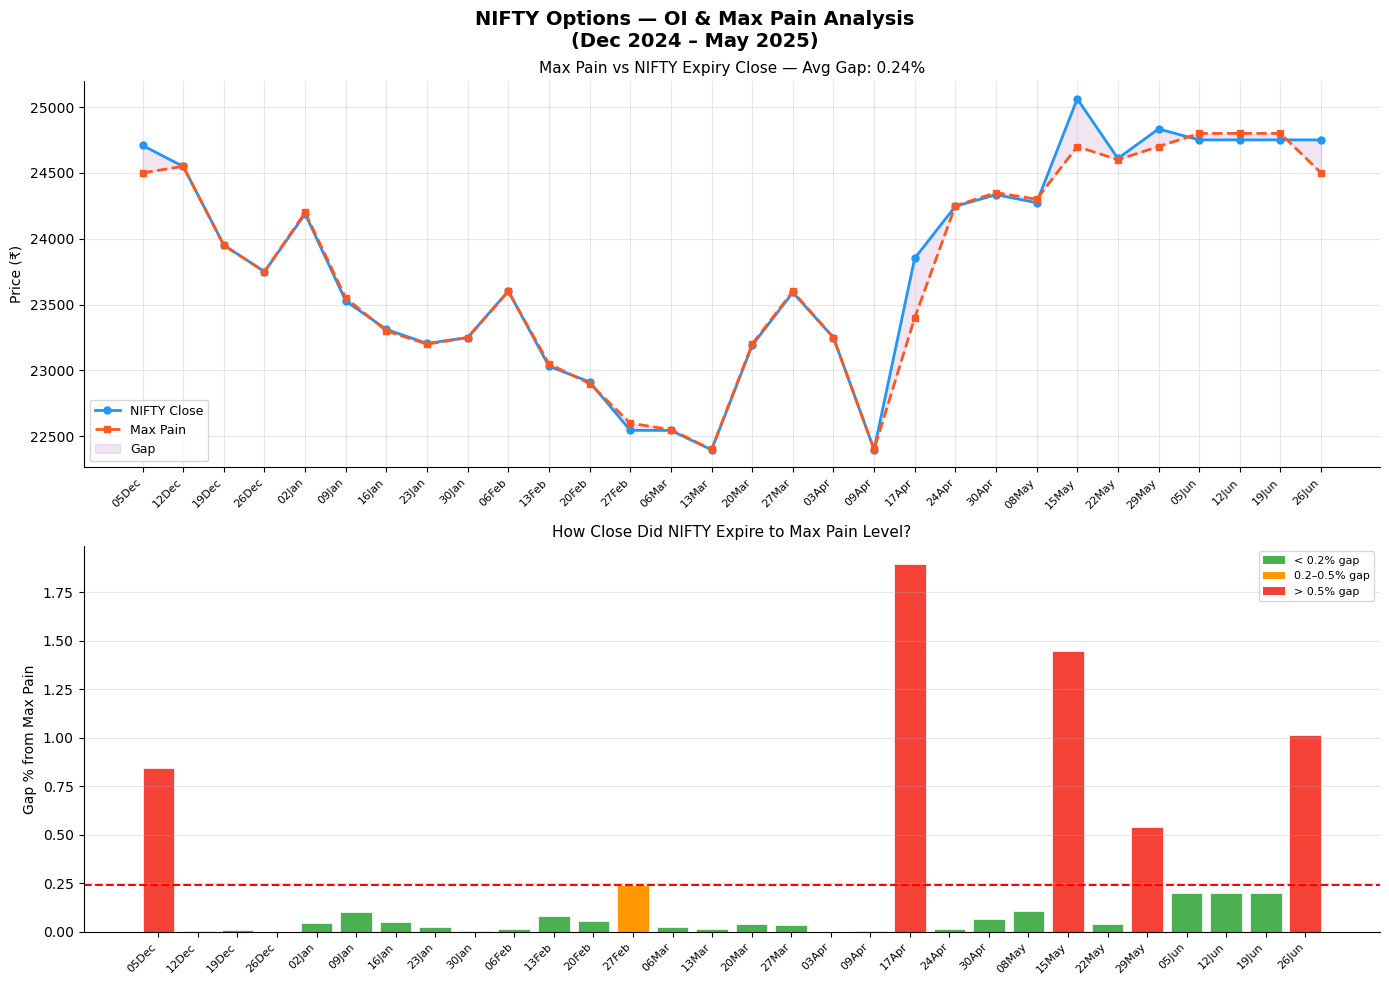

✅ Chart saved


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("NIFTY Options — OI & Max Pain Analysis\n(Dec 2024 – May 2025)", 
             fontsize=14, fontweight="bold")

# ── Plot 1: Max Pain vs Underlying Close ──────────────
ax1 = axes[0]
x = range(len(mp_df))

ax1.plot(x, mp_df["underlying_close"], 
         color="#2196F3", linewidth=2, marker="o", markersize=5, label="NIFTY Close")
ax1.plot(x, mp_df["max_pain"], 
         color="#FF5722", linewidth=2, marker="s", markersize=5, 
         linestyle="--", label="Max Pain")

ax1.fill_between(x, mp_df["underlying_close"], mp_df["max_pain"], 
                 alpha=0.1, color="purple", label="Gap")

ax1.set_xticks(x)
ax1.set_xticklabels(
    mp_df["expiry"].dt.strftime("%d%b"), 
    rotation=45, ha="right", fontsize=8
)
ax1.set_ylabel("Price (₹)", fontsize=10)
ax1.set_title(f"Max Pain vs NIFTY Expiry Close — Avg Gap: {mp_df['diff_pct'].mean():.2f}%", 
              fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── Plot 2: Gap % per expiry ──────────────────────────
ax2 = axes[1]
bars = ax2.bar(x, mp_df["diff_pct"], 
               color=["#4CAF50" if v < 0.2 else "#FF9800" if v < 0.5 else "#F44336" 
                      for v in mp_df["diff_pct"]],
               edgecolor="white", linewidth=0.5)

ax2.axhline(y=mp_df["diff_pct"].mean(), color="red", 
            linestyle="--", linewidth=1.5,
            label=f"Average: {mp_df['diff_pct'].mean():.2f}%")

ax2.set_xticks(x)
ax2.set_xticklabels(
    mp_df["expiry"].dt.strftime("%d%b"), 
    rotation=45, ha="right", fontsize=8
)
ax2.set_ylabel("Gap % from Max Pain", fontsize=10)
ax2.set_title("How Close Did NIFTY Expire to Max Pain Level?", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="< 0.2% gap"),
    Patch(facecolor="#FF9800", label="0.2–0.5% gap"),
    Patch(facecolor="#F44336", label="> 0.5% gap")
]
ax2.legend(handles=legend_elements, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("../data/processed/max_pain_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

In [13]:
# ── Put Call Ratio Analysis ────────────────────────────
# PCR = Total PE OI / Total CE OI on each day

pcr_daily = df_near.groupby(["date", "option_type"])["open_interest"].sum().unstack()
pcr_daily.columns = ["CE_OI", "PE_OI"]
pcr_daily["PCR"] = pcr_daily["PE_OI"] / pcr_daily["CE_OI"]
pcr_daily = pcr_daily.reset_index()

# ── Get NIFTY direction next day ──────────────────────
# Use underlying price to calculate next day return
daily_underlying = df.groupby("date")["underlying_price"].median().reset_index()
daily_underlying = daily_underlying.sort_values("date")
daily_underlying["next_day_return"] = daily_underlying["underlying_price"].pct_change().shift(-1) * 100
daily_underlying["next_day_direction"] = daily_underlying["next_day_return"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

# Merge PCR with direction
pcr_analysis = pcr_daily.merge(daily_underlying, on="date", how="inner")
pcr_analysis = pcr_analysis.dropna(subset=["PCR", "next_day_direction"])

# ── PCR Signal Logic ──────────────────────────────────
# Oversold signal: PCR > 1.2 → market likely to go UP (too many puts = reversal)
# Overbought signal: PCR < 0.8 → market likely to go DOWN (too many calls = reversal)

def pcr_signal(pcr):
    if pcr > 1.2:
        return "BULLISH"   # contrarian — too many puts
    elif pcr < 0.8:
        return "BEARISH"   # contrarian — too many calls
    else:
        return "NEUTRAL"

pcr_analysis["signal"] = pcr_analysis["PCR"].apply(pcr_signal)

# ── Accuracy Calculation ──────────────────────────────
bullish = pcr_analysis[pcr_analysis["signal"] == "BULLISH"]
bearish = pcr_analysis[pcr_analysis["signal"] == "BEARISH"]

bull_accuracy = (bullish["next_day_direction"] == "UP").mean() * 100
bear_accuracy = (bearish["next_day_direction"] == "DOWN").mean() * 100
overall = len(bullish) + len(bearish)
overall_correct = (bullish["next_day_direction"] == "UP").sum() + \
                  (bearish["next_day_direction"] == "DOWN").sum()
overall_accuracy = overall_correct / overall * 100 if overall > 0 else 0

print(f"PCR Statistics:")
print(f"  Average PCR      : {pcr_analysis['PCR'].mean():.3f}")
print(f"  PCR Range        : {pcr_analysis['PCR'].min():.3f} → {pcr_analysis['PCR'].max():.3f}")
print(f"\nSignal Distribution:")
print(pcr_analysis["signal"].value_counts())
print(f"\nAccuracy:")
print(f"  Bullish signal accuracy : {bull_accuracy:.1f}% ({len(bullish)} signals)")
print(f"  Bearish signal accuracy : {bear_accuracy:.1f}% ({len(bearish)} signals)")
print(f"  Overall accuracy        : {overall_accuracy:.1f}%")

PCR Statistics:
  Average PCR      : 0.879
  PCR Range        : 0.498 → 1.290

Signal Distribution:
signal
NEUTRAL    75
BEARISH    43
BULLISH     4
Name: count, dtype: int64

Accuracy:
  Bullish signal accuracy : 50.0% (4 signals)
  Bearish signal accuracy : 65.1% (43 signals)
  Overall accuracy        : 63.8%


Adjusted Signal Distribution:
signal_v2
BEARISH    62
NEUTRAL    45
BULLISH    15
Name: count, dtype: int64

Adjusted Accuracy:
  Bullish : 66.7% (15 signals)
  Bearish : 59.7% (62 signals)
  Overall : 61.0%


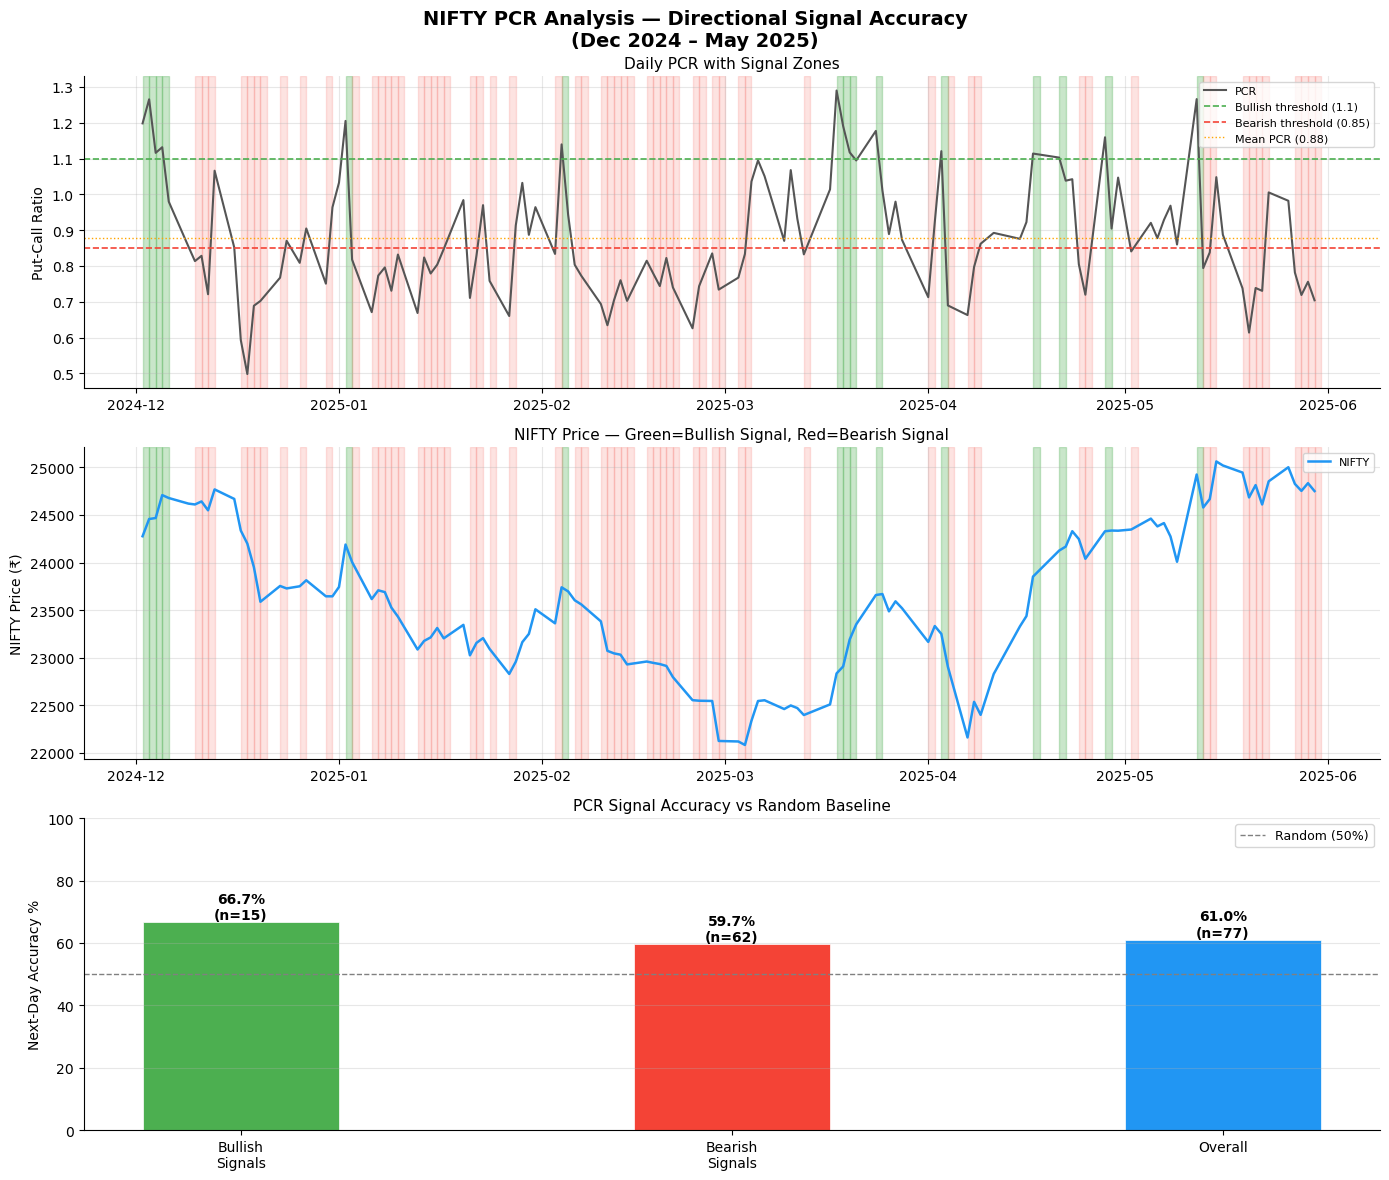

✅ Chart saved


In [15]:
# ── Adjust thresholds for this market regime ──────────
def pcr_signal_v2(pcr):
    if pcr > 1.1:
        return "BULLISH"
    elif pcr < 0.85:
        return "BEARISH"
    else:
        return "NEUTRAL"

pcr_analysis["signal_v2"] = pcr_analysis["PCR"].apply(pcr_signal_v2)

bullish2 = pcr_analysis[pcr_analysis["signal_v2"] == "BULLISH"]
bearish2 = pcr_analysis[pcr_analysis["signal_v2"] == "BEARISH"]

bull_acc2 = (bullish2["next_day_direction"] == "UP").mean() * 100
bear_acc2 = (bearish2["next_day_direction"] == "DOWN").mean() * 100
total2    = len(bullish2) + len(bearish2)
correct2  = (bullish2["next_day_direction"] == "UP").sum() + \
            (bearish2["next_day_direction"] == "DOWN").sum()
overall2  = correct2 / total2 * 100 if total2 > 0 else 0

print(f"Adjusted Signal Distribution:")
print(pcr_analysis["signal_v2"].value_counts())
print(f"\nAdjusted Accuracy:")
print(f"  Bullish : {bull_acc2:.1f}% ({len(bullish2)} signals)")
print(f"  Bearish : {bear_acc2:.1f}% ({len(bearish2)} signals)")
print(f"  Overall : {overall2:.1f}%")

# ── Plot PCR Analysis ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("NIFTY PCR Analysis — Directional Signal Accuracy\n(Dec 2024 – May 2025)",
             fontsize=14, fontweight="bold")

# Plot 1: PCR over time with signals
ax1 = axes[0]
ax1.plot(pcr_analysis["date"], pcr_analysis["PCR"],
         color="#555", linewidth=1.5, label="PCR")
ax1.axhline(y=1.1, color="#4CAF50", linestyle="--", linewidth=1.2, label="Bullish threshold (1.1)")
ax1.axhline(y=0.85, color="#F44336", linestyle="--", linewidth=1.2, label="Bearish threshold (0.85)")
ax1.axhline(y=pcr_analysis["PCR"].mean(), color="orange", 
            linestyle=":", linewidth=1, label=f"Mean PCR ({pcr_analysis['PCR'].mean():.2f})")

# Shade signal zones
bull_dates = pcr_analysis[pcr_analysis["signal_v2"] == "BULLISH"]["date"]
bear_dates = pcr_analysis[pcr_analysis["signal_v2"] == "BEARISH"]["date"]

for d in bull_dates:
    ax1.axvspan(d, d + pd.Timedelta(days=1), alpha=0.3, color="#4CAF50")
for d in bear_dates:
    ax1.axvspan(d, d + pd.Timedelta(days=1), alpha=0.15, color="#F44336")

ax1.set_ylabel("Put-Call Ratio", fontsize=10)
ax1.set_title("Daily PCR with Signal Zones", fontsize=11)
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Plot 2: NIFTY underlying with signal overlay
ax2 = axes[1]
ax2.plot(pcr_analysis["date"], pcr_analysis["underlying_price"],
         color="#2196F3", linewidth=1.8, label="NIFTY")

for d in bull_dates:
    ax2.axvspan(d, d + pd.Timedelta(days=1), alpha=0.3, color="#4CAF50")
for d in bear_dates:
    ax2.axvspan(d, d + pd.Timedelta(days=1), alpha=0.15, color="#F44336")

ax2.set_ylabel("NIFTY Price (₹)", fontsize=10)
ax2.set_title("NIFTY Price — Green=Bullish Signal, Red=Bearish Signal", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Plot 3: Accuracy bar chart
ax3 = axes[2]
categories = ["Bullish\nSignals", "Bearish\nSignals", "Overall"]
accuracies = [bull_acc2, bear_acc2, overall2]
counts     = [len(bullish2), len(bearish2), total2]
colors_bar = ["#4CAF50", "#F44336", "#2196F3"]

bars = ax3.bar(categories, accuracies, color=colors_bar, 
               edgecolor="white", linewidth=0.5, width=0.4)
ax3.axhline(y=50, color="gray", linestyle="--", linewidth=1, label="Random (50%)")

for bar, acc, cnt in zip(bars, accuracies, counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%\n(n={cnt})", ha="center", fontsize=10, fontweight="bold")

ax3.set_ylabel("Next-Day Accuracy %", fontsize=10)
ax3.set_title("PCR Signal Accuracy vs Random Baseline", fontsize=11)
ax3.set_ylim(0, 100)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis="y")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../data/processed/pcr_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

In [16]:
# ── IV Behavior Around Expiry ──────────────────────────
# We'll use proxy IV: ATM option premium / underlying price * sqrt(365/dte)
# This is simplified IV estimation without Black-Scholes

iv_data = df_near[
    (df_near["moneyness"] == "ATM") &
    (df_near["dte"] >= 1) &
    (df_near["dte"] <= 15) &
    (df_near["close"] > 0) &
    (df_near["underlying_price"] > 0)
].copy()

# Simplified IV proxy
iv_data["iv_proxy"] = (iv_data["close"] / iv_data["underlying_price"]) * \
                       np.sqrt(365 / iv_data["dte"]) * 100

# Remove outliers
iv_data = iv_data[iv_data["iv_proxy"] < 100]

# Average IV by DTE
iv_curve = iv_data.groupby(["dte", "option_type"])["iv_proxy"].median().reset_index()
iv_curve.columns = ["dte", "option_type", "iv_proxy"]
iv_curve = iv_curve.sort_values("dte", ascending=False)

# IV by expiry — to spot IV crush
iv_by_expiry = iv_data.groupby(["expiry", "option_type"])["iv_proxy"].agg(["mean","std"]).reset_index()
iv_by_expiry.columns = ["expiry", "option_type", "avg_iv", "iv_std"]
iv_by_expiry["expiry"] = pd.to_datetime(iv_by_expiry["expiry"])
iv_by_expiry = iv_by_expiry.sort_values("expiry")

print("IV Proxy by DTE:")
print(iv_curve.to_string(index=False))

IV Proxy by DTE:
 dte option_type  iv_proxy
  15          PE  5.347155
  15          CE  6.849331
  14          PE  5.121025
  14          CE  6.485825
  13          PE  5.286070
  13          CE  6.539003
  12          PE  4.088391
  12          CE  5.072677
  10          PE  5.404950
  10          CE  7.135620
   9          CE  6.763982
   9          PE  5.539618
   8          PE  5.625611
   8          CE  6.534176
   7          PE  5.350364
   7          CE  6.229284
   6          PE  5.425523
   6          CE  6.036449
   5          PE  5.354363
   5          CE  5.215751
   3          PE  6.088563
   3          CE  7.271681
   2          PE  6.178810
   2          CE  7.043643
   1          PE  7.473471
   1          CE  6.912823


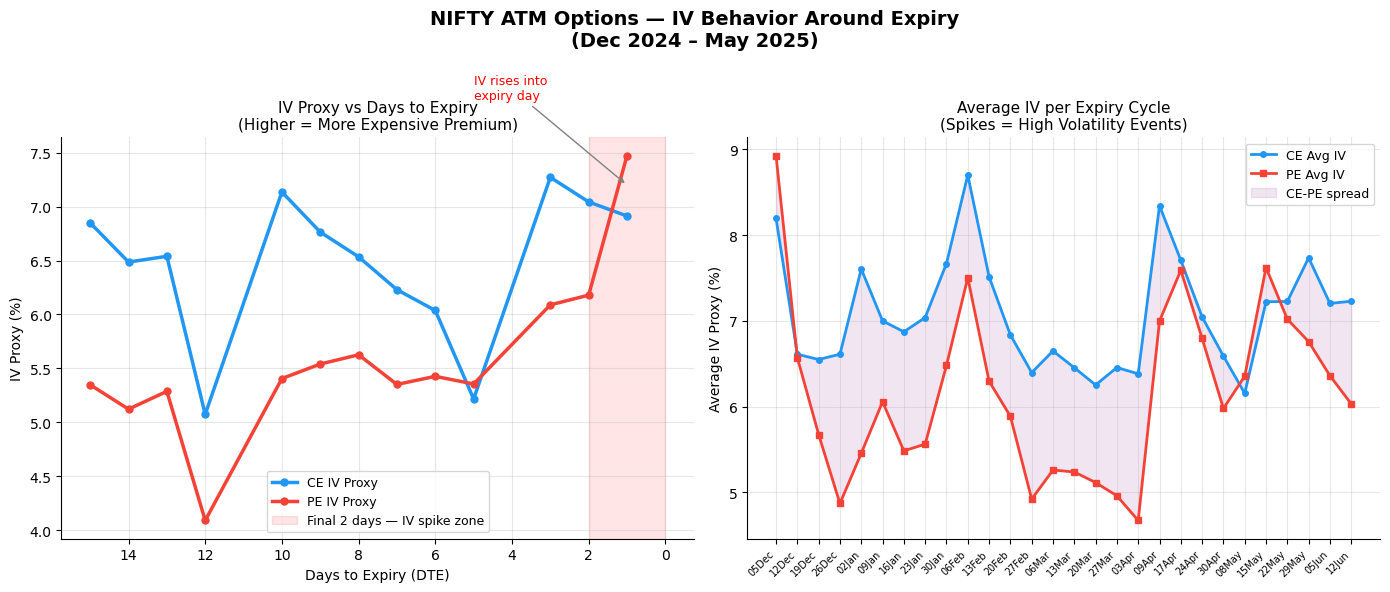

✅ Chart saved


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("NIFTY ATM Options — IV Behavior Around Expiry\n(Dec 2024 – May 2025)",
             fontsize=14, fontweight="bold")

colors = {"CE": "#2196F3", "PE": "#F44336"}

# Plot 1: IV curve by DTE
ax1 = axes[0]
for opt in ["CE", "PE"]:
    data = iv_curve[iv_curve["option_type"] == opt].sort_values("dte")
    ax1.plot(data["dte"], data["iv_proxy"],
             color=colors[opt], linewidth=2.5, marker="o", 
             markersize=5, label=f"{opt} IV Proxy")

ax1.axvspan(0, 2, alpha=0.1, color="red", label="Final 2 days — IV spike zone")
ax1.invert_xaxis()
ax1.set_xlabel("Days to Expiry (DTE)", fontsize=10)
ax1.set_ylabel("IV Proxy (%)", fontsize=10)
ax1.set_title("IV Proxy vs Days to Expiry\n(Higher = More Expensive Premium)", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Annotate the spike
ax1.annotate("IV rises into\nexpiry day",
             xy=(1, 7.2), xytext=(5, 8),
             arrowprops=dict(arrowstyle="->", color="gray"),
             fontsize=9, color="red")

# Plot 2: Average IV per expiry cycle
ax2 = axes[1]
ce_iv = iv_by_expiry[iv_by_expiry["option_type"] == "CE"].sort_values("expiry")
pe_iv = iv_by_expiry[iv_by_expiry["option_type"] == "PE"].sort_values("expiry")

x = range(len(ce_iv))
ax2.plot(x, ce_iv["avg_iv"].values, color="#2196F3", 
         linewidth=2, marker="o", markersize=4, label="CE Avg IV")
ax2.plot(x, pe_iv["avg_iv"].values, color="#F44336",
         linewidth=2, marker="s", markersize=4, label="PE Avg IV")
ax2.fill_between(x, ce_iv["avg_iv"].values, pe_iv["avg_iv"].values,
                 alpha=0.1, color="purple", label="CE-PE spread")

ax2.set_xticks(x)
ax2.set_xticklabels(
    ce_iv["expiry"].dt.strftime("%d%b"),
    rotation=45, ha="right", fontsize=7
)
ax2.set_ylabel("Average IV Proxy (%)", fontsize=10)
ax2.set_title("Average IV per Expiry Cycle\n(Spikes = High Volatility Events)", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../data/processed/iv_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")